In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
from io import StringIO
import nltk
from nltk.tokenize import sent_tokenize
import random
import re

In [24]:
# specify file path on google drive and the local folder to which it should be saved
file_id = "1DUgfdEhSo425FA2LJbpgFKH8Jr2jAHV_"
url = f"https://drive.google.com/uc?id={file_id}&export=download"
output = "../01_data/parlspeech_dataset.csv"

# download the dataset
# gdown.download(url, output, quiet=False)

# load it as a pandas df and show first rows
# df = pd.read_csv(output)

# read it from the local directory
parlspeech_df = pd.read_csv("../01_data/parlspeech_dataset.csv")

# read in the dictionary df
group_dictionary_df = pd.read_csv("../01_data/groups_dictionary.csv")

In [26]:
# convert date column to datetime and extract month and year
parlspeech_df["date"] = pd.to_datetime(parlspeech_df["date"])
parlspeech_df["month"] = parlspeech_df["date"].dt.month
parlspeech_df["year"] = parlspeech_df["date"].dt.year

# show first rows
parlspeech_df.head()

,date,agenda,speechnumber,speaker,party,party.facts.id,chair,terms,text,parliament,iso3country,month,year
0,1988-11-22,Queen's Speech,1,CHAIR,NaN,NaN,True,74,I have to acquaint the House that this House h...,UK-HouseOfCommons,GBR,11,1988
1,1988-11-22,First Day [Debate On The Address],2,CHAIR,NaN,NaN,True,55,It may be for the convenience of the House if ...,UK-HouseOfCommons,GBR,11,1988
2,1988-11-22,First Day [Debate On The Address],3,Giles Shaw,Con,1567.0,False,2511,"I beg to move,. That an humble Address be pres...",UK-HouseOfCommons,GBR,11,1988
3,1988-11-22,First Day [Debate On The Address],4,John Maples,Con,1567.0,False,1470,I am delighted to second the motion. When I ha...,UK-HouseOfCommons,GBR,11,1988
4,1988-11-22,First Day [Debate On The Address],5,Neil Kinnock,Lab,1516.0,False,2768,I am sure that I speak for the majority of hon...,UK-HouseOfCommons,GBR,11,1988


<function matplotlib.pyplot.show(close=None, block=None)>

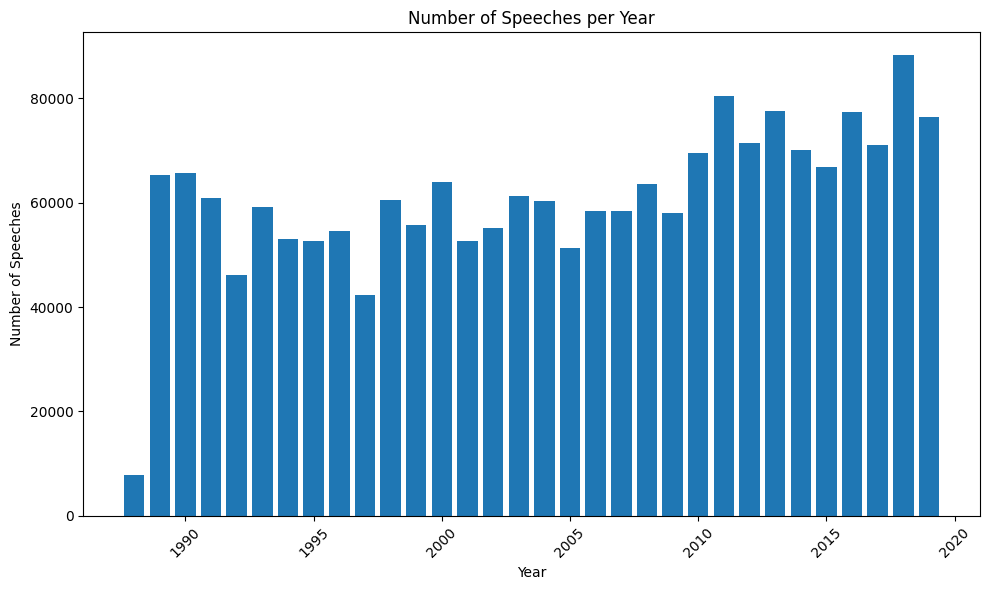

In [27]:
# get number of speeches per year and plot development over time
speeches_per_year = parlspeech_df.groupby("year").size()

plt.figure(figsize=(10, 6))
plt.bar(speeches_per_year.index, speeches_per_year)
plt.xlabel("Year")
plt.ylabel("Number of Speeches")
plt.title("Number of Speeches per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

In [34]:
# reduce the df to only speeches from 2010 onwards
parlspeech_df_subset = parlspeech_df[parlspeech_df["year"] >= 2010].copy()

In [35]:
def clean_text(text):
    """Convert to string, fix encoding issues, normalize spaces."""
    if not isinstance(text, str):
        return ""
    # Handle encoding errors safely
    text = str(text).encode("utf-8", "ignore").decode("utf-8")
    # Remove weird whitespace and normalize
    text = re.sub(r'\s+', ' ', text)
    # Strip leading/trailing spaces
    text = text.strip()
    return text

def split_sentences(text):
    """Split clean text into sentences."""
    if not text:
        return []
    return sent_tokenize(text)

# Apply cleaning
parlspeech_df_subset['clean_speech'] = parlspeech_df_subset['text'].apply(clean_text)

# Apply sentence splitting
parlspeech_df_subset['sentences'] = parlspeech_df_subset['clean_speech'].apply(split_sentences)

In [38]:
sentences_df = parlspeech_df_subset[['sentences']].explode('sentences').reset_index(drop=True)
sentences_df = sentences_df.rename(columns={'sentences': 'sentence'})
sentences_df.head()
len(sentences_df)

6110104

In [39]:
sentences_df.head()

,sentence
0,I regret to have to report to the House the de...
1,"David was a highly assiduous, principled and i..."
2,"Truly, he was a House of Commons man, and I am..."
3,What recent steps his Department has taken to ...
4,What steps his Department has taken to reduce ...


In [62]:
patterns = [word for col in group_dictionary_df.columns for word in group_dictionary_df[col] if pd.notna(word)]

regex_patterns = []
for pat in patterns:
    if pat.startswith('* '):  # one word before
        word = pat[2:]
        regex_patterns.append(rf'\b\w+ {re.escape(word)}\b')
    elif pat.endswith('*') and ' ' not in pat:  # suffix match
        word = pat[:-1]
        regex_patterns.append(rf'\b{re.escape(word)}\w*\b')
    elif pat.endswith(' *'):  # one word after
        word = pat[:-2]
        regex_patterns.append(rf'\b{re.escape(word)} \w+\b')
    else:
        regex_patterns.append(rf'\b{re.escape(pat)}\b')  # exact match

combined_regex = "|".join(regex_patterns)

filtered_df = sentences_df[sentences_df["sentence"].str.contains(combined_regex, flags=re.IGNORECASE, regex=True)]

unmatched_df = sentences_df[~sentences_df["sentence"].isin(filtered_df["sentence"])]

In [68]:
unmatched_df = sentences_df[~sentences_df["sentence"].isin(filtered_df["sentence"])]

In [69]:
len(unmatched_df)

5476319

In [73]:
# randomly sample sentences from both subsets
sample_matches = filtered_df.sample(n=50, random_state=42)
sample_nonmatches = unmatched_df.sample(n=50, random_state=42)

# concatenate the two
sample_annotations = pd.concat([sample_matches, sample_nonmatches]).sample(frac=1)

In [75]:
# export as plain text
sample_annotations["sentence"].to_csv("../01_data/sample_annotations.txt", index=False, header=False)

In [89]:
sample_annotations["sentence"].iloc[2]

'In an increasingly global economy, it is not surprising that many skilled workers come to the UK for a short time to fill a temporary skills gap, or perhaps to experience work in another country, but-this is an important point-reducing migration is not just about reducing the numbers coming here.'